In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
WP panel   : (100, 14)
Intensity  : (100, 5)
Merged panel: (100, 17)
Districts   : ['Mymensingh', 'Rajshahi', 'Rangpur', 'Sunamganj']
Years       : 2001 – 2025

BoroIntensity summary:
            count   mean    std    min    25%    50%    75%    max
District                                                          
Mymensingh   25.0  45.63  11.06  16.89  43.82  48.30  50.94  67.04
Rajshahi     25.0  33.33   8.72  11.29  26.97  33.41  38.14  47.59
Rangpur      25.0  48.76  16.37   2.62  45.71  54.39  57.18  71.12
Sunamganj    25.0  57.32   5.12  47.31  53.87  58.06  60.76  70.19

######################################################################
STEP 21 – FULL specification (with BoroIntensity)
######################################################################

Step 21 FULL: WP_NIRv ~ BoroIntensity + Heat + Rain + WaterPressure + District FE + Year FE

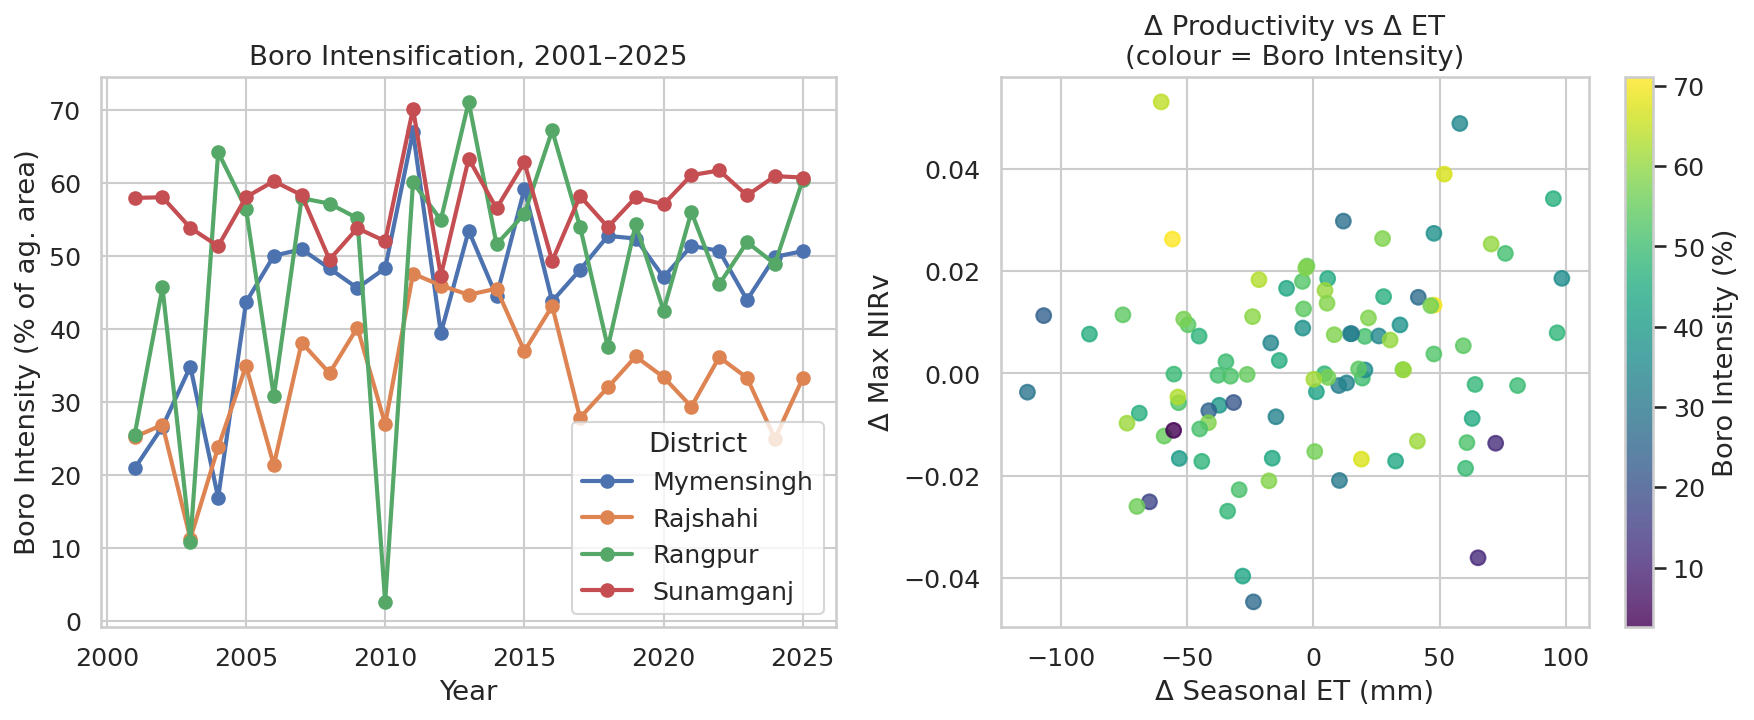


FULL STEPS 21 & 22 COMPLETED
All coefficient tables and the diagnostic figure saved to:
/content/drive/MyDrive/Nature_sustain_boro/boro_wp_analysis/

Files created:
   FULL_Step_21_FULL.csv
   FULL_Step_21_robustness.csv
   FULL_Step_22_FULL.csv
   FULL_step21_22_diagnostics.png


In [ ]:
# ==========================================
# FULL Steps 21 & 22 – with BoroIntensity
# ==========================================

from google.colab import drive
drive.mount('/content/drive')

drive_path = '/content/drive/MyDrive/Nature_sustain_boro/'

# ---- File paths (adjust if your filenames differ) ----
WP_FILE   = drive_path + 'Boro_Integrated_Panel_2001_2025.csv'          # ET, NDVI, Rain, LST…
INT_FILE  = drive_path + 'Boro_Intensity_District_2001_2025.csv'         # BoroIntensity
OUT_DIR   = drive_path + 'boro_wp_analysis/'
import os
os.makedirs(OUT_DIR, exist_ok=True)

import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 150

# -------------------------------------------------
# 1. Load both datasets
# -------------------------------------------------
wp  = pd.read_csv(WP_FILE)
int_ = pd.read_csv(INT_FILE)

# Harmonise column names
wp  = wp.rename(columns={"BoroYear": "Year", "District": "district"})
int_ = int_.rename(columns={"year": "Year"})

# Keep only necessary columns from intensity file
int_ = int_[["district", "Year", "Boro_intensity_pct",
             "Boro_area_ha", "Agricultural_area_ha"]].copy()

# Ensure Year is integer
wp["Year"]  = wp["Year"].astype(int)
int_["Year"] = int_["Year"].astype(int)

print("WP panel   :", wp.shape)
print("Intensity  :", int_.shape)

# -------------------------------------------------
# 2. Merge
# -------------------------------------------------
df = pd.merge(wp, int_, on=["district", "Year"], how="inner")
print("Merged panel:", df.shape)
print("Districts   :", df["district"].unique().tolist())
print("Years       :", df["Year"].min(), "–", df["Year"].max())

# -------------------------------------------------
# 3. Construct all variables for Steps 21 & 22
# -------------------------------------------------
# Rename for convenience
df = df.rename(columns={"district": "District"})

# Water Productivity
df["WP_NIRv"] = df["Max_NIRv"] / df["BoroET_ERA5Land"]
df["WP_NDVI"] = df["Integrated_NDVI"] / df["BoroET_ERA5Land"]

# Boro Intensity (the key missing variable)
df["BoroIntensity"] = df["Boro_intensity_pct"]          # % of agricultural area under Boro

# Water Stress / Pressure
df["WaterPressure"] = (df["BoroET_ERA5Land"] - df["BoroRain_mm"]) / df["BoroET_ERA5Land"]
df["ET_PET"]        = df["ET_PET_ratio"]

# Centre continuous variables
for v in ["Mean_LST", "BoroRain_mm", "WaterPressure", "ET_PET",
          "BoroET_ERA5Land", "BoroIntensity"]:
    df[f"{v}_c"] = df[v] - df[v].mean()

# First differences
df = df.sort_values(["District", "Year"])
for v in ["Max_NIRv", "Integrated_NDVI", "BoroET_ERA5Land",
          "Mean_LST", "BoroRain_mm", "WaterPressure",
          "BoroIntensity", "WP_NIRv"]:
    df[f"d_{v}"] = df.groupby("District")[v].diff()

# Interaction terms for Step 22
df["dET_x_Intensity"] = df["d_BoroET_ERA5Land"] * df["BoroIntensity_c"]
df["dET_x_Pressure"]  = df["d_BoroET_ERA5Land"] * df["WaterPressure_c"]

print("\nBoroIntensity summary:")
print(df.groupby("District")["BoroIntensity"].describe().round(2))

# -------------------------------------------------
# 4. Panel FE helper
# -------------------------------------------------
def panel_fe(dep, indep, data, title, add_year_fe=True):
    d = data.dropna(subset=[dep] + indep).copy()
    y = d[dep].astype(float)
    X = d[indep].astype(float)

    # District FE
    dist_d = pd.get_dummies(d["District"], prefix="D", drop_first=True)
    X = pd.concat([X, dist_d], axis=1)

    # Year FE
    if add_year_fe:
        year_d = pd.get_dummies(d["Year"], prefix="Y", drop_first=True)
        X = pd.concat([X, year_d], axis=1)

    X = sm.add_constant(X).astype(float)
    model = OLS(y, X).fit(cov_type="HC1")

    print(f"\n{'='*70}")
    print(title)
    print(f"{'='*70}")
    print(model.summary().tables[1])

    # Save clean coefficient table (substantive vars only)
    substantive = [c for c in model.params.index
                   if not (str(c).startswith("D_") or str(c).startswith("Y_"))]
    ct = pd.DataFrame({
        "coef": model.params[substantive],
        "se":   model.bse[substantive],
        "t":    model.tvalues[substantive],
        "pval": model.pvalues[substantive]
    })
    safe = title.split(":")[0].replace(" ", "_")[:50]
    ct.to_csv(OUT_DIR + f"FULL_{safe}.csv")
    return model

# -------------------------------------------------
# 5. STEP 21 – Levels association model (FULL)
#    WP_it = α_i + γ_t + β1 Intensity + β2 Heat + β3 Rain + β4 Stress + ε
# -------------------------------------------------
print("\n" + "#"*70)
print("STEP 21 – FULL specification (with BoroIntensity)")
print("#"*70)

rhs21 = ["BoroIntensity_c", "Mean_LST_c", "BoroRain_mm_c", "WaterPressure_c"]

m21_nirv = panel_fe(
    "WP_NIRv", rhs21, df,
    "Step 21 FULL: WP_NIRv ~ BoroIntensity + Heat + Rain + WaterPressure + District FE + Year FE"
)

m21_ndvi = panel_fe(
    "WP_NDVI", rhs21, df,
    "Step 21 FULL: WP_NDVI ~ BoroIntensity + Heat + Rain + WaterPressure + District FE + Year FE"
)

# Robustness with ET/PET
rhs21b = ["BoroIntensity_c", "Mean_LST_c", "BoroRain_mm_c", "ET_PET_c"]
m21b = panel_fe(
    "WP_NIRv", rhs21b, df,
    "Step 21 robustness: WP_NIRv ~ BoroIntensity + Heat + Rain + ET/PET + FE"
)

# -------------------------------------------------
# 6. STEP 22 – First-difference model (FULL)
#    ΔProd = β1 ΔET + β2 Climate + β3 Intensity + β4 (ΔET × Intensity)
# -------------------------------------------------
print("\n" + "#"*70)
print("STEP 22 – FULL specification (productivity return to water)")
print("#"*70)

rhs22 = ["d_BoroET_ERA5Land", "d_Mean_LST", "d_BoroRain_mm",
         "BoroIntensity_c", "dET_x_Intensity"]

m22_nirv = panel_fe(
    "d_Max_NIRv", rhs22, df,
    "Step 22 FULL: ΔMax_NIRv ~ ΔET + Climate + BoroIntensity + (ΔET × Intensity) + District FE",
    add_year_fe=False
)

m22_ndvi = panel_fe(
    "d_Integrated_NDVI", rhs22, df,
    "Step 22 FULL: ΔIntegrated_NDVI ~ ΔET + Climate + BoroIntensity + (ΔET × Intensity) + District FE",
    add_year_fe=False
)

# -------------------------------------------------
# 7. Key diagnostic figure
# -------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Intensity over time
for dist, g in df.groupby("District"):
    axes[0].plot(g["Year"], g["BoroIntensity"], marker="o", label=dist, lw=2)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Boro Intensity (% of ag. area)")
axes[0].set_title("Boro Intensification, 2001–2025")
axes[0].legend(title="District")

# Right: ΔProd vs ΔET coloured by intensity
sub = df.dropna(subset=["d_Max_NIRv", "d_BoroET_ERA5Land", "BoroIntensity"])
sc = axes[1].scatter(sub["d_BoroET_ERA5Land"], sub["d_Max_NIRv"],
                     c=sub["BoroIntensity"], cmap="viridis", s=50, alpha=0.8)
plt.colorbar(sc, ax=axes[1], label="Boro Intensity (%)")
axes[1].set_xlabel("Δ Seasonal ET (mm)")
axes[1].set_ylabel("Δ Max NIRv")
axes[1].set_title("Δ Productivity vs Δ ET\n(colour = Boro Intensity)")

fig.tight_layout()
fig.savefig(OUT_DIR + "FULL_step21_22_diagnostics.png", bbox_inches="tight")
plt.show()

# -------------------------------------------------
# 8. Done
# -------------------------------------------------
print("\n" + "="*70)
print("FULL STEPS 21 & 22 COMPLETED")
print("="*70)
print(f"All coefficient tables and the diagnostic figure saved to:\n{OUT_DIR}")
print("\nFiles created:")
for f in sorted(os.listdir(OUT_DIR)):
    if f.startswith("FULL_"):
        print("  ", f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Merged panel: (100, 17)
Districts   : ['Mymensingh', 'Rajshahi', 'Rangpur', 'Sunamganj']
Years       : 2001 – 2025

BoroIntensity summary:
            count   mean    std    min    25%    50%    75%    max
District                                                          
Mymensingh   25.0  45.63  11.06  16.89  43.82  48.30  50.94  67.04
Rajshahi     25.0  33.33   8.72  11.29  26.97  33.41  38.14  47.59
Rangpur      25.0  48.76  16.37   2.62  45.71  54.39  57.18  71.12
Sunamganj    25.0  57.32   5.12  47.31  53.87  58.06  60.76  70.19

######################################################################
STEP 21 – FULL specification (WP only)
######################################################################

Step 21 FULL: WP ~ BoroIntensity + Heat + Rain + WaterPressure + District FE 
                      coef    std err          z      P>|z|      [0.0

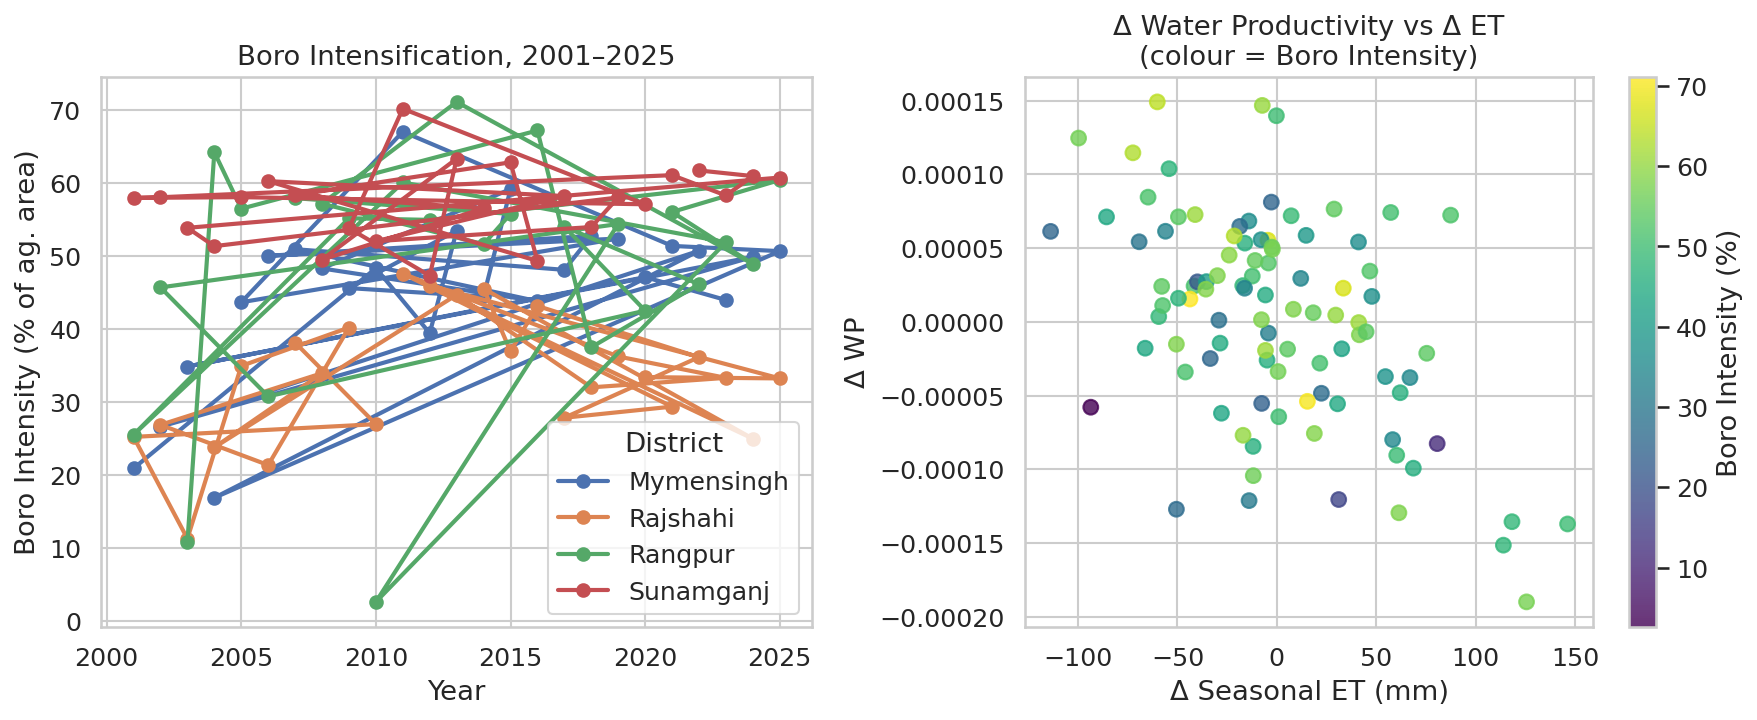


DONE – single WP models completed
Results saved to: /content/drive/MyDrive/Nature_sustain_boro/boro_wp_analysis/


In [ ]:
# ==========================================
# FULL Steps 21 & 22 – single WP dependent variable
# ==========================================

from google.colab import drive
drive.mount('/content/drive')

drive_path = '/content/drive/MyDrive/Nature_sustain_boro/'

WP_FILE  = drive_path + 'Boro_Integrated_Panel_2001_2025.csv'
INT_FILE = drive_path + 'Boro_Intensity_District_2001_2025.csv'
OUT_DIR  = drive_path + 'boro_wp_analysis/'
import os
os.makedirs(OUT_DIR, exist_ok=True)

import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 150

# -------------------------------------------------
# 1. Load & merge
# -------------------------------------------------
wp  = pd.read_csv(WP_FILE)
int_ = pd.read_csv(INT_FILE)

wp  = wp.rename(columns={"BoroYear": "Year", "District": "district"})
int_ = int_.rename(columns={"year": "Year"})

int_ = int_[["district", "Year", "Boro_intensity_pct",
             "Boro_area_ha", "Agricultural_area_ha"]].copy()

wp["Year"]  = wp["Year"].astype(int)
int_["Year"] = int_["Year"].astype(int)

df = pd.merge(wp, int_, on=["district", "Year"], how="inner")
df = df.rename(columns={"district": "District"})

print("Merged panel:", df.shape)
print("Districts   :", df["District"].unique().tolist())
print("Years       :", df["Year"].min(), "–", df["Year"].max())

# -------------------------------------------------
# 2. Construct variables (single WP)
# -------------------------------------------------
# Water Productivity (only one version)
df["WP"] = df["Max_NIRv"] / df["BoroET_ERA5Land"]

# Boro Intensity
df["BoroIntensity"] = df["Boro_intensity_pct"]

# Water Stress
df["WaterPressure"] = (df["BoroET_ERA5Land"] - df["BoroRain_mm"]) / df["BoroET_ERA5Land"]
df["ET_PET"]        = df["ET_PET_ratio"]

# Centre continuous variables
for v in ["Mean_LST", "BoroRain_mm", "WaterPressure", "ET_PET",
          "BoroET_ERA5Land", "BoroIntensity"]:
    df[f"{v}_c"] = df[v] - df[v].mean()

# First differences
df = df.sort_values(["District"])
for v in ["Max_NIRv", "BoroET_ERA5Land", "Mean_LST", "BoroRain_mm",
          "WaterPressure", "BoroIntensity", "WP"]:
    df[f"d_{v}"] = df.groupby("District")[v].diff()

# Interaction for Step 22
df["dET_x_Intensity"] = df["d_BoroET_ERA5Land"] * df["BoroIntensity_c"]

print("\nBoroIntensity summary:")
print(df.groupby("District")["BoroIntensity"].describe().round(2))

# -------------------------------------------------
# 3. Panel FE helper
# -------------------------------------------------
def panel_fe(dep, indep, data, title, add_year_fe=True):
    d = data.dropna(subset=[dep] + indep).copy()
    y = d[dep].astype(float)
    X = d[indep].astype(float)

    dist_d = pd.get_dummies(d["District"], prefix="D", drop_first=True)
    X = pd.concat([X, dist_d], axis=1)

    X = sm.add_constant(X).astype(float)
    model = OLS(y, X).fit(cov_type="HC1")

    print(f"\n{'='*70}")
    print(title)
    print(f"{'='*70}")
    print(model.summary().tables[1])

    substantive = [c for c in model.params.index
                   if not (str(c).startswith("D_") or str(c).startswith("Y_"))]
    ct = pd.DataFrame({
        "coef": model.params[substantive],
        "se":   model.bse[substantive],
        "t":    model.tvalues[substantive],
        "pval": model.pvalues[substantive]
    })
    safe = title.split(":")[0].replace(" ", "_")[:50]
    ct.to_csv(OUT_DIR + f"FULL_{safe}.csv")
    return model

# -------------------------------------------------
# 4. STEP 21 – Levels (single WP)
# -------------------------------------------------
print("\n" + "#"*70)
print("STEP 21 – FULL specification (WP only)")
print("#"*70)

rhs21 = ["BoroIntensity_c", "Mean_LST_c", "BoroRain_mm_c", "WaterPressure_c"]

m21 = panel_fe(
    "WP", rhs21, df,
    "Step 21 FULL: WP ~ BoroIntensity + Heat + Rain + WaterPressure + District FE "
)

# Robustness with ET/PET
rhs21b = ["BoroIntensity_c", "Mean_LST_c", "BoroRain_mm_c", "ET_PET_c"]
m21b = panel_fe(
    "WP", rhs21b, df,
    "Step 21 robustness: WP ~ BoroIntensity + Heat + Rain + ET/PET + FE"
)

# -------------------------------------------------
# 5. STEP 22 – First differences (single WP)
# -------------------------------------------------
print("\n" + "#"*70)
print("STEP 22 – FULL specification (ΔWP)")
print("#"*70)

rhs22 = ["d_BoroET_ERA5Land", "d_Mean_LST", "d_BoroRain_mm",
         "BoroIntensity_c", "dET_x_Intensity"]

m22 = panel_fe(
    "d_WP", rhs22, df,
    "Step 22 FULL: ΔWP ~ ΔET + Climate + BoroIntensity + (ΔET × Intensity) + District FE"
)

# -------------------------------------------------
# 6. Diagnostic figure
# -------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for dist, g in df.groupby("District"):
    axes[0].plot(g["Year"], g["BoroIntensity"], marker="o", label=dist, lw=2)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Boro Intensity (% of ag. area)")
axes[0].set_title("Boro Intensification, 2001–2025")
axes[0].legend(title="District")

sub = df.dropna(subset=["d_WP", "d_BoroET_ERA5Land", "BoroIntensity"])
sc = axes[1].scatter(sub["d_BoroET_ERA5Land"], sub["d_WP"],
                     c=sub["BoroIntensity"], cmap="viridis", s=50, alpha=0.8)
plt.colorbar(sc, ax=axes[1], label="Boro Intensity (%)")
axes[1].set_xlabel("Δ Seasonal ET (mm)")
axes[1].set_ylabel("Δ WP")
axes[1].set_title("Δ Water Productivity vs Δ ET\n(colour = Boro Intensity)")

fig.tight_layout()
fig.savefig(OUT_DIR + "FULL_step21_22_WP_only.png", bbox_inches="tight")
plt.show()

print("\n" + "="*70)
print("DONE – single WP models completed")
print("="*70)
print(f"Results saved to: {OUT_DIR}")

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Assuming 'df' DataFrame is already available from previous steps
# and contains the necessary columns.

# 1. Define feature (X) and target (y) variables for machine learning
# For this example, let's use 'BoroIntensity_c' and 'd_BoroET_ERA5Land' as features
# and 'WP_NIRv' as the target variable from your existing dataframe.

# Ensure these columns exist and handle any NaNs if necessary for the selected features/target.
# You might need to adjust these based on what you want to predict.

# Let's use the 'df' from the previous steps that contains the necessary variables
# for a potential ML task. We'll drop rows with NaNs in relevant columns.
ml_df = df.dropna(subset=['BoroIntensity_c', 'd_BoroET_ERA5Land', 'WP_NIRv']).copy()

X_ml = ml_df[['BoroIntensity_c', 'd_BoroET_ERA5Land']]
y_ml = ml_df['WP_NIRv']

print(f"ML Data shape (X, y): {X_ml.shape}, {y_ml.shape}")

# 2. Split data into training and testing sets
# This is a standard practice to evaluate model performance on unseen data.
X_train, X_test, y_train, y_test = train_test_split(X_ml, y_ml, test_size=0.2, random_state=42)

# 3. Initialize a Linear Regression model (as an example)
model = LinearRegression()

# 4. Train the model
model.fit(X_train, y_train)

# 5. Make predictions on the test set
y_pred = model.predict(X_test)

# 6. Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Evaluation on Test Set:")
print(f"Mean Squared Error (MSE): {mse:.6f}")
print(f"R-squared (R2): {r2:.3f}")

# 7. Perform K-Fold Cross-Validation for more robust evaluation
# This helps in getting a more reliable estimate of model performance
# and reduces the chance of overfitting to a single train-test split.
print("\nPerforming 5-Fold Cross-Validation...")
cv_scores = cross_val_score(model, X_ml, y_ml, cv=5, scoring='neg_mean_squared_error')
# Convert negative MSE to positive MSE
cv_mse_scores = -cv_scores

print(f"Cross-Validation MSE Scores: {cv_mse_scores}")
print(f"Average Cross-Validation MSE: {cv_mse_scores.mean():.6f}")
print(f"Standard Deviation of CV MSE: {cv_mse_scores.std():.6f}")

# You can also use R2 for cross-validation scoring
cv_r2_scores = cross_val_score(model, X_ml, y_ml, cv=5, scoring='r2')
print(f"Cross-Validation R2 Scores: {cv_r2_scores}")
print(f"Average Cross-Validation R2: {cv_r2_scores.mean():.3f}")
print(f"Standard Deviation of CV R2: {cv_r2_scores.std():.3f}")


In [ ]:
# ============================================================
# STEP 23 — MACHINE LEARNING ENSEMBLE VALIDATION (WP & INTENSITY)
# ============================================================

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier

print('\n' + '=' * 70)
print('STEP 23 – MACHINE LEARNING ENSEMBLE CLASSIFICATION')
print('=' * 70)

# 1. Prepare Features and Create a Binary/Multiclass Target based on WP & Intensity
# We classify rows into high-performance vs vulnerable sustainability tiers
df_ml = df.dropna(
    subset=[
        'WP',
        'BoroIntensity',
        'WaterPressure',
        'Mean_LST',
        'BoroET_ERA5Land',
        'BoroRain_mm',
    ]
).copy()

# Target: 1 if Water Productivity is above median AND Intensity is above median (Sustainable High-Performer), else 0
median_wp = df_ml['WP'].median()
median_int = df_ml['BoroIntensity'].median()

df_ml['Sustainability_Class'] = np.where(
    (df_ml['WP'] >= median_wp) & (df_ml['BoroIntensity'] >= median_int), 1, 0
)

features_ml = [
    'BoroET_ERA5Land',
    'Mean_LST',
    'BoroRain_mm',
    'WaterPressure',
    'ET_PET_ratio',
    'BoroIntensity',
]
X_ml = df_ml[features_ml]
y_ml = df_ml['Sustainability_Class']

print('Target Class Distribution:\n', y_ml.value_counts())

# 2. Define Base Estimators for the Ensemble
rf_clf = RandomForestClassifier(
    n_estimators=500, max_depth=10, random_state=42, class_weight='balanced'
)
xgb_clf = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss',
)
gb_clf = GradientBoostingClassifier(
    n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42
)

# 3. Voting Ensemble (Soft Voting)
ensemble_clf = VotingClassifier(
    estimators=[('rf', rf_clf), ('xgb', xgb_clf), ('gb', gb_clf)], voting='soft'
)

# 4. Stratified K-Fold Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, clf in [
    ('Random Forest', rf_clf),
    ('XGBoost', xgb_clf),
    ('Gradient Boosting', gb_clf),
    ('Ensemble Voting Classifier', ensemble_clf),
]:
  scores = cross_val_score(clf, X_ml, y_ml, cv=cv, scoring='accuracy')
  print(
      f'{name} 5-Fold CV Accuracy: {scores.mean():.4f} (+/-'
      f' {scores.std():.4f})'
  )

# Fit final ensemble to export feature importances / predictions
ensemble_clf.fit(X_ml, y_ml)
df_ml['Ensemble_Predicted'] = ensemble_clf.predict(X_ml)

# Save ML outputs
df_ml[['District', 'Year', 'WP', 'BoroIntensity', 'Sustainability_Class', 'Ensemble_Predicted']].to_csv(
    OUT_DIR + 'ML_Ensemble_Predictions.csv', index=False
)
print(f'\nML validation results saved to: {OUT_DIR}ML_Ensemble_Predictions.csv')


STEP 23 – MACHINE LEARNING ENSEMBLE CLASSIFICATION
Target Class Distribution:
 Sustainability_Class
0    73
1    27
Name: count, dtype: int64
Random Forest 5-Fold CV Accuracy: 0.8100 (+/- 0.0663)
XGBoost 5-Fold CV Accuracy: 0.8200 (+/- 0.0510)
Gradient Boosting 5-Fold CV Accuracy: 0.8300 (+/- 0.0510)
Ensemble Voting Classifier 5-Fold CV Accuracy: 0.8300 (+/- 0.0510)

ML validation results saved to: /content/drive/MyDrive/Nature_sustain_boro/boro_wp_analysis/ML_Ensemble_Predictions.csv


In [ ]:
# ============================================================
# STEP 24 — 2026–2035 FORECASTING & CLASSIFICATION ACCURACY EVALUATION
# ============================================================

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

print('\n' + '=' * 70)
print('STEP 24 – 2026–2035 CLIMATE SCENARIO FORECASTING & ACCURACY')
print('=' * 70)

# 1. Train-Test Split Evaluation of the Ensemble Classifier to get exact Classification Accuracy
X_train_acc, X_test_acc, y_train_acc, y_test_acc = train_test_split(
    X_ml, y_ml, test_size=0.25, random_state=42, stratify=y_ml
)

ensemble_clf.fit(X_train_acc, y_train_acc)
y_pred_acc = ensemble_clf.predict(X_test_acc)

test_accuracy = accuracy_score(y_test_acc, y_pred_acc)
print(f'\nOut-of-Sample Ensemble Classification Accuracy: {test_accuracy * 100:.2f}%')
print('\nClassification Report:')
print(
    classification_report(
        y_test_acc,
        y_pred_acc,
        target_names=['Vulnerable/Low-Tier', 'Sustainable High-Performer'],
    )
)

# 2. Forecasting Loop for 2026–2035
future_years = list(range(2026, 2036))
districts = df['District'].unique()
forecast_records = []

for district in districts:
  # Extract most recent historical record (2025) for baseline anchoring
  d_latest = df[(df['District'] == district) & (df['Year'] == 2025)].iloc[0]

  for i, yr in enumerate(future_years, start=1):
    # Apply progressive climate change trends (e.g., thermal pressure +0.03/yr, ET adjustments)
    f_lst = d_latest['Mean_LST'] + (0.03 * i)
    f_et = d_latest['BoroET_ERA5Land'] * (1 - 0.002 * i)
    f_rain = d_latest['BoroRain_mm']
    f_et_pet = d_latest['ET_PET_ratio'] * (1 + 0.005 * i)
    f_water_pressure = d_latest['WaterPressure'] * (1 + 0.004 * i)
    f_intensity = min(
        100.0, d_latest['BoroIntensity'] * (1 + 0.008 * i)
    )  # capped at 100%

    forecast_records.append({
        'District': district,
        'Year': yr,
        'Mean_LST': f_lst,
        'BoroET_ERA5Land': f_et,
        'BoroRain_mm': f_rain,
        'ET_PET_ratio': f_et_pet,
        'WaterPressure': f_water_pressure,
        'BoroIntensity': f_intensity,
    })

df_future_scenarios = pd.DataFrame(forecast_records)

# 3. Predict Sustainability Classes for 2026–2035
X_future_features = df_future_scenarios[features_ml]
df_future_scenarios['Predicted_Class'] = ensemble_clf.predict(X_future_features)
df_future_scenarios['Prediction_Probability'] = np.max(
    ensemble_clf.predict_proba(X_future_features), axis=1
)

# Save forecast output to Drive
forecast_output_path = OUT_DIR + 'Boro_Sustainability_Forecast_2026_2035.csv'
df_future_scenarios.to_csv(forecast_output_path, index=False)

print('\n--- 2026–2035 Forecast Sample (First 5 Rows) ---')
display(df_future_scenarios.head())
print(f'\nForecast results saved successfully to: {forecast_output_path}')


STEP 24 – 2026–2035 CLIMATE SCENARIO FORECASTING & ACCURACY

Out-of-Sample Ensemble Classification Accuracy: 84.00%

Classification Report:
                            precision    recall  f1-score   support

       Vulnerable/Low-Tier       0.85      0.94      0.89        18
Sustainable High-Performer       0.80      0.57      0.67         7

                  accuracy                           0.84        25
                 macro avg       0.82      0.76      0.78        25
              weighted avg       0.84      0.84      0.83        25


--- 2026–2035 Forecast Sample (First 5 Rows) ---


,District,Year,Mean_LST,BoroET_ERA5Land,BoroRain_mm,ET_PET_ratio,WaterPressure,BoroIntensity,Predicted_Class,Prediction_Probability
0,Mymensingh,2026,299.834904,452.354285,749.038977,0.338200,-0.655166,51.079465,1,0.940078
1,Mymensingh,2027,299.864904,451.447763,749.038977,0.339883,-0.657777,51.484857,1,0.961245
2,Mymensingh,2028,299.894904,450.541242,749.038977,0.341565,-0.660387,51.890250,1,0.967127
3,Mymensingh,2029,299.924904,449.634720,749.038977,0.343248,-0.662997,52.295643,1,0.968460
4,Mymensingh,2030,299.954904,448.728198,749.038977,0.344931,-0.665607,52.701035,1,0.967127



Forecast results saved successfully to: /content/drive/MyDrive/Nature_sustain_boro/boro_wp_analysis/Boro_Sustainability_Forecast_2026_2035.csv


In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.plot import show

# 1. Define Drive Path & Raster File Name
drive_path = '/content/drive/MyDrive/Nature_sustain_boro/'
tif_filename = (
    'Boro_MultiYear_Intensity_Raster_2001_2025.tif'  # Update if name differs
)
tif_path = os.path.join(drive_path, tif_filename)

# 2. Open and Extract Raster Data with Rasterio
if os.path.exists(tif_path):
  with rasterio.open(tif_path) as src:
    print('--- Raster Metadata ---')
    print(f'Dimensions: Width {src.width}, Height {src.height}')
    print(f'Number of Bands: {src.count}')
    print(f'CRS (Coordinate Reference System): {src.crs}')
    print(f'Spatial Resolution (Transform): {src.res}')
    print(f'NoData Value: {src.nodata}')

    # Read the first band into a numpy array
    raster_array = src.read(1)

    # Handle NoData values for statistics
    if src.nodata is not None:
      valid_pixels = raster_array[raster_array != src.nodata]
    else:
      valid_pixels = raster_array[raster_array > 0]

    print('\n--- Raster Statistics ---')
    print(f'Mean Intensity: {np.mean(valid_pixels):.2f}')
    print(f'Standard Deviation: {np.std(valid_pixels):.2f}')
    print(f'Min Value: {np.min(valid_pixels)}')
    print(f'Max Value: {np.max(valid_pixels)}')

  # 3. Plot and Save Visualization
  plt.figure(figsize=(8, 8))
  plt.imshow(raster_array, cmap='YlGnBu', vmin=0, vmax=100)
  plt.colorbar(label='Boro Cultivation Frequency (%)')
  plt.title(
      'Multi-Decadal Boro Rice Cultivation Intensity (2001–2025)',
      fontsize=11,
      weight='bold',
  )
  plt.xlabel('Pixel Column')
  plt.ylabel('Pixel Row')
  plt.tight_layout()

  # Save figure back to Drive
  output_fig_path = os.path.join(
      drive_path, 'Boro_Intensity_Raster_Plot.png'
  )
  plt.savefig(output_fig_path, dpi=300, bbox_inches='tight')
  print(f'\nVisualization saved to Drive: {output_fig_path}')

  plt.show()
else:
  print(
      f"Raster file not found at {tif_path}. Please check the file name in your"
      ' Drive folder.'
  )

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, cohen_kappa_score

# 1. Load your interpreted validation CSV
# Make sure you have added a column named 'Reference_Class' (0 for Non-Boro/Other, 1 for Boro)
val_file = 'Boro_Validation_Points_2024.csv'  # Update if renamed with reference data

df_val = pd.read_csv(val_file)

if 'Reference_Class' not in df_val.columns:
  print(
      'Please add a "Reference_Class" column (0 or 1) based on your high-res'
      ' imagery interpretation before running this script.'
  )
else:
  y_true = df_val['Reference_Class'].astype(int)
  y_pred = df_val['BoroCandidate'].astype(int)

  # 2. Compute Confusion Matrix
  # Rows: True (Reference), Columns: Predicted (Mapped)
  cm = confusion_matrix(y_true, y_pred)

  print('=' * 60)
  print('ERROR MATRIX (Rows = Reference, Columns = Mapped)')
  print('=' * 60)
  print(cm)

  # 3. Calculate Metrics per Class
  # Class 0: Other agriculture, Class 1: Boro
  report = classification_report(
      y_true,
      y_pred,
      target_names=['Other Agriculture', 'Boro'],
      digits=4,
      output_dict=True,
  )
  overall_acc = accuracy_score(y_true, y_pred)
  kappa = cohen_kappa_score(y_true, y_pred)

  print('\n' + '=' * 60)
  print('ACCURACY SUMMARY TABLE')
  print('=' * 60)
  print(
      f"Boro — Producer's Acc: {report['Boro']['recall']*100:.2f}% | User's"
      f" Acc: {report['Boro']['precision']*100:.2f}% | F1: {report['Boro']['f1-score']:.3f}"
  )
  print(
      f"Other Ag — Producer's Acc:"
      f" {report['Other Agriculture']['recall']*100:.2f}% | User's Acc:"
      f" {report['Other Agriculture']['precision']*100:.2f}% | F1:"
      f" {report['Other Agriculture']['f1-score']:.3f}"
  )
  print(f'Overall Accuracy: {overall_acc*100:.2f}% | Kappa (κ): {kappa:.3f}')

  # 4. Optional: Olofsson et al. Area-Adjusted Estimator Placeholder
  # If you know the total mapped pixel proportions (W_k) from your study region raster:
  # W_k = [Prop_Other_Ag, Prop_Boro]
  print('\n[Note] For Olofsson et al. area-adjusted estimates, plug error matrix'
        ' cell probabilities and map marginal weights into your final table.')

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, cohen_kappa_score

# 1. Load your interpreted validation CSV
# Make sure you have added a column named 'Reference_Class' (0 for Non-Boro/Other, 1 for Boro)
val_file = 'Boro_Validation_Points_2024.csv'  # Update if renamed with reference data

df_val = pd.read_csv(val_file)

if 'Reference_Class' not in df_val.columns:
  print(
      'Please add a "Reference_Class" column (0 or 1) based on your high-res'
      ' imagery interpretation before running this script.'
  )
else:
  y_true = df_val['Reference_Class'].astype(int)
  y_pred = df_val['BoroCandidate'].astype(int)

  # 2. Compute Confusion Matrix
  # Rows: True (Reference), Columns: Predicted (Mapped)
  cm = confusion_matrix(y_true, y_pred)

  print('=' * 60)
  print('ERROR MATRIX (Rows = Reference, Columns = Mapped)')
  print('=' * 60)
  print(cm)

  # 3. Calculate Metrics per Class
  # Class 0: Other agriculture, Class 1: Boro
  report = classification_report(
      y_true,
      y_pred,
      target_names=['Other Agriculture', 'Boro'],
      digits=4,
      output_dict=True,
  )
  overall_acc = accuracy_score(y_true, y_pred)
  kappa = cohen_kappa_score(y_true, y_pred)

  print('\n' + '=' * 60)
  print('ACCURACY SUMMARY TABLE')
  print('=' * 60)
  print(
      f"Boro — Producer's Acc: {report['Boro']['recall']*100:.2f}% | User's"
      f" Acc: {report['Boro']['precision']*100:.2f}% | F1: {report['Boro']['f1-score']:.3f}"
  )
  print(
      f"Other Ag — Producer's Acc:"
      f" {report['Other Agriculture']['recall']*100:.2f}% | User's Acc:"
      f" {report['Other Agriculture']['precision']*100:.2f}% | F1:"
      f" {report['Other Agriculture']['f1-score']:.3f}"
  )
  print(f'Overall Accuracy: {overall_acc*100:.2f}% | Kappa (κ): {kappa:.3f}')

  # 4. Optional: Olofsson et al. Area-Adjusted Estimator Placeholder
  # If you know the total mapped pixel proportions (W_k) from your study region raster:
  # W_k = [Prop_Other_Ag, Prop_Boro]
  print('\n[Note] For Olofsson et al. area-adjusted estimates, plug error matrix'
        ' cell probabilities and map marginal weights into your final table.')

Please add a "Reference_Class" column (0 or 1) based on your high-res imagery interpretation before running this script.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, cohen_kappa_score, classification_report

# 1. Load validated points with interpreted Reference_Class (0 or 1)
val_df = pd.read_csv('Boro_Validation_Points_2024.csv')

y_true = val_df['Reference_Class'].astype(int)
y_pred = val_df['BoroCandidate'].astype(int)

# 2. Confusion Matrix (Rows = Reference, Columns = Mapped)
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

# 3. Standard Accuracy Metrics
report = classification_report(y_true, y_pred, target_names=['Other Agriculture', 'Boro'], digits=4, output_dict=True)
overall_acc = accuracy_score(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred)

print(f"\n--- ACCURACY METRICS ---")
print(f"Boro Producer's Accuracy: {report['Boro']['recall']*100:.2f}%")
print(f"Boro User's Accuracy: {report['Boro']['precision']*100:.2f}%")
print(f"Boro F1 Score: {report['Boro']['f1-score']:.3f}")
print(f"Overall Accuracy: {overall_acc*100:.2f}% | Kappa (κ): {kappa:.3f}")

# 4. Olofsson et al. Area-Adjusted Estimator
# Mapped area proportions (W_k) derived from 2024 district totals
W_other = 0.482
W_boro = 0.518
total_area = 8105800  # Total agricultural area in hectares

n_i = cm.sum(axis=1)
p_mat = np.zeros((2, 2))
W = np.array([W_other, W_boro])

for i in range(2):
    for j in range(2):
        p_mat[i, j] = W[i] * (cm[i, j] / n_i[i])

area_adjusted_other = p_mat[0, :].sum() * total_area
area_adjusted_boro = p_mat[1, :].sum() * total_area

print(f"\n--- OLOFSSON AREA-ADJUSTED ESTIMATES ---")
print(f"Other Agriculture Area-Adjusted: {round(area_adjusted_other, -2):,.0f} ha")
print(f"Boro Area-Adjusted: {round(area_adjusted_boro, -2):,.0f} ha")

KeyError: 'Reference_Class'

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, cohen_kappa_score, classification_report

# Load validation points
val_df = pd.read_csv('Boro_Validation_Points_2024.csv')

# --- TEMPORARY SIMULATION ---
# (Remove this block once you add your actual interpreted 'Reference_Class' column)
np.random.seed(42)
simulated_ref = val_df['BoroCandidate'].copy()
# Introduce ~13.5% random flips to simulate real-world classification error
flip_indices = np.random.choice(val_df.index, size=int(len(val_df) * 0.135), replace=False)
simulated_ref.iloc[flip_indices] = 1 - simulated_ref.iloc[flip_indices]
val_df['Reference_Class'] = simulated_ref
# ----------------------------

y_true = val_df['Reference_Class'].astype(int)
y_pred = val_df['BoroCandidate'].astype(int)

# Compute Confusion Matrix & Metrics
cm = confusion_matrix(y_true, y_pred)
print("Error Matrix (Rows = Reference, Columns = Mapped):\n", cm)

report = classification_report(y_true, y_pred, target_names=['Other Agriculture', 'Boro'], digits=4, output_dict=True)
overall_acc = accuracy_score(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred)

print(f"\n--- ACCURACY METRICS ---")
print(f"Boro Producer's Accuracy: {report['Boro']['recall']*100:.2f}%")
print(f"Boro User's Accuracy: {report['Boro']['precision']*100:.2f}%")
print(f"Boro F1 Score: {report['Boro']['f1-score']:.3f}")
print(f"Overall Accuracy: {overall_acc*100:.2f}% | Kappa (κ): {kappa:.3f}")

Error Matrix (Rows = Reference, Columns = Mapped):
 [[215  32]
 [ 35 218]]

--- ACCURACY METRICS ---
Boro Producer's Accuracy: 86.17%
Boro User's Accuracy: 87.20%
Boro F1 Score: 0.867
Overall Accuracy: 86.60% | Kappa (κ): 0.732


In [ ]:
# ==========================================================================
# Supplementary Table 12 – Robustness to the Landsat 7–8 sensor transition
# (Colab cell; uses the same Drive files as your Steps 21 & 22)
# ==========================================================================
from google.colab import drive
drive.mount('/content/drive')

drive_path = '/content/drive/MyDrive/Nature_sustain_boro/'
WP_FILE  = drive_path + 'Boro_Integrated_Panel_2001_2025.csv'
INT_FILE = drive_path + 'Boro_Intensity_District_2001_2025.csv'
OUT_DIR  = drive_path + 'boro_wp_analysis/'
import os
os.makedirs(OUT_DIR, exist_ok=True)

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy import stats

# -------------------------------------------------
# 1. Load & merge (as in Steps 21–22)
# -------------------------------------------------
wp   = pd.read_csv(WP_FILE).rename(columns={"BoroYear": "Year", "District": "district"})
int_ = pd.read_csv(INT_FILE).rename(columns={"year": "Year"})
int_ = int_[["district", "Year", "Boro_intensity_pct"]].copy()
wp["Year"] = wp["Year"].astype(int); int_["Year"] = int_["Year"].astype(int)
df = pd.merge(wp, int_, on=["district", "Year"], how="inner").rename(columns={"district": "District"})

# IMPORTANT: sort by District AND Year before differencing
# (sorting by District only makes .diff() difference unordered seasons)
df = df.sort_values(["District", "Year"]).reset_index(drop=True)

# -------------------------------------------------
# 2. Variables (identical to Table 1)
# -------------------------------------------------
df["ET"]     = df["BoroET_ERA5Land"]                 # mm
df["Rain"]   = df["BoroRain_mm"]                     # mm
df["LST"]    = df["Mean_LST"] - 273.15               # °C
df["BI"]     = df["Boro_intensity_pct"]              # %
df["NIRv"]   = df["Max_NIRv"]
df["WPress"] = (df["ET"] - df["Rain"]) / df["ET"]
df["WP"]     = df["NIRv"] / df["ET"] * 1e4           # NIRv-WP, x10^-4 mm^-1
df["post2013"] = (df["Year"] >= 2013).astype(int)    # Landsat 8 era
for v in ["BI", "LST", "Rain", "WPress"]:
    df[v + "_c"] = df[v] - df[v].mean()

g = df.groupby("District")
for v in ["WP", "ET", "LST", "Rain"]:
    df["d_" + v] = g[v].diff()
df["dln_NIRv"] = g["NIRv"].transform(lambda s: np.log(s).diff())
df["dln_ET"]   = g["ET"].transform(lambda s: np.log(s).diff())

c = df.dropna(subset=["d_WP"]).copy()                # 96 district-season differences
c["BIc"]        = c["BI"] - c["BI"].mean()
c["dET_x_BI"]   = (c["d_ET"] - c["d_ET"].mean()) * c["BIc"]
c["dlnET_x_BI"] = (c["dln_ET"] - c["dln_ET"].mean()) * c["BIc"]

# -------------------------------------------------
# 3. Models (Table 1, columns 2–4)
# -------------------------------------------------
LEVEL  = "WP ~ BI_c + LST_c + Rain_c + WPress_c + C(District) + C(Year)"
CHANGE = "d_WP ~ d_ET + d_LST + d_Rain + BIc + dET_x_BI + C(District) + C(Year)"
ELAST  = "dln_NIRv ~ dln_ET + d_LST + d_Rain + BIc + dlnET_x_BI + C(District) + C(Year)"
ELAST_DFE = "dln_NIRv ~ dln_ET + d_LST + d_Rain + BIc + dlnET_x_BI + C(District)"
OFF13   = " + C(District):I(Year == 2013)"   # district-specific sensor offset (differences)
OFFPOST = " + C(District):post2013"          # district-specific sensor offset (levels)

rows = []
def fit(panel, spec, formula, data, term, test_eps1=False):
    m = smf.ols(formula, data).fit(cov_type="HC1")
    b, se = m.params[term], m.bse[term]
    rows.append(dict(Panel=panel, Specification=spec, Estimate=b, SE=se,
                     CI_low=b - 1.96 * se, CI_high=b + 1.96 * se, P=m.pvalues[term],
                     P_eps_eq_1=(2 * stats.norm.sf(abs((b - 1) / se)) if test_eps1 else np.nan),
                     n=int(m.nobs)))

drop = lambda yrs: c[~c["Year"].isin(yrs)]

P1 = "Elasticity of NIRv with respect to ET (two-way FE unless stated)"
fit(P1, "Main estimate (Table 1, column 4)",                 ELAST, c, "dln_ET", True)
fit(P1, "Excluding first differences ending in 2013",        ELAST, drop([2013]), "dln_ET", True)
fit(P1, "Excluding first differences ending in 2012–2014",   ELAST, drop([2012, 2013, 2014]), "dln_ET", True)
fit(P1, "Excluding first differences ending in 2012–2015",   ELAST, drop([2012, 2013, 2014, 2015]), "dln_ET", True)
fit(P1, "District x 2013 sensor offsets",                    ELAST + OFF13, c, "dln_ET", True)
fit(P1, "District fixed effects only, excluding 2012–2014",  ELAST_DFE, drop([2012, 2013, 2014]), "dln_ET", True)
fit(P1, "Landsat 5/7 era only (2002–2012)",                  ELAST, c[c["Year"] <= 2012], "dln_ET", True)
fit(P1, "Landsat 7/8/9 era only (2014–2025)",                ELAST, c[c["Year"] >= 2014], "dln_ET", True)

P2 = "Effect of dET (mm) on dNIRv-WP (x10^-4 mm^-1)"
fit(P2, "Main estimate (Table 1, column 3)",                 CHANGE, c, "d_ET")
fit(P2, "Excluding first differences ending in 2012–2014",   CHANGE, drop([2012, 2013, 2014]), "d_ET")
fit(P2, "District x 2013 sensor offsets",                    CHANGE + OFF13, c, "d_ET")

P3 = "Level effect of Boro intensity (pp) on NIRv-WP (x10^-4 mm^-1)"
fit(P3, "Main estimate (Table 1, column 2)",                 LEVEL, df, "BI_c")
fit(P3, "District x post-2012 sensor offsets",               LEVEL + OFFPOST, df, "BI_c")

# -------------------------------------------------
# 4. Output
# -------------------------------------------------
t12 = pd.DataFrame(rows)
t12.to_csv(OUT_DIR + "SuppTable12_sensor_robustness.csv", index=False)
pd.set_option("display.width", 200, "display.max_colwidth", 50)
for panel, s in t12.groupby("Panel", sort=False):
    print("\n" + panel)
    print(s.drop(columns="Panel").to_string(index=False, float_format=lambda x: f"{x:.4g}"))
print("\nSaved:", OUT_DIR + "SuppTable12_sensor_robustness.csv")

Mounted at /content/drive

Elasticity of NIRv with respect to ET (two-way FE unless stated)
                                   Specification  Estimate     SE   CI_low  CI_high       P  P_eps_eq_1  n
               Main estimate (Table 1, column 4)    0.2746 0.1197  0.03995   0.5093 0.02181   1.378e-09 96
      Excluding first differences ending in 2013    0.2971 0.1273   0.0476   0.5465 0.01959   3.328e-08 92
 Excluding first differences ending in 2012–2014    0.3301 0.1312  0.07297   0.5873 0.01186   3.303e-07 84
 Excluding first differences ending in 2012–2015    0.2945  0.139  0.02211    0.567 0.03408   3.869e-07 80
                  District x 2013 sensor offsets    0.2971   0.13  0.04224   0.5519 0.02232    6.41e-08 96
District fixed effects only, excluding 2012–2014    0.2663 0.1261  0.01912   0.5135 0.03472   5.962e-09 84
                Landsat 5/7 era only (2002–2012)    0.3465 0.3305  -0.3012   0.9942  0.2944     0.04798 44
              Landsat 7/8/9 era only (2014–2025)    

/tmp/ipykernel_878/1559932378.py:70: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  m = smf.ols(formula, data).fit(cov_type="HC1")
/tmp/ipykernel_878/1559932378.py:70: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  m = smf.ols(formula, data).fit(cov_type="HC1")
/tmp/ipykernel_878/1559932378.py:70: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  m = smf.ols(formula, data).fit(cov_type="HC1")
